# Phase 6: Baseline Segmentation

**Objective:**
Create a simple baseline segmentation model to serve as a reference point for more sophisticated clustering approaches. Before modeling, we must preprocess the skewed RFM features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## 1. Load RFM Data & Preprocessing
As observed in Phase 5, Frequency and Monetary are highly right-skewed. K-Means is extremely sensitive to variance and outliers. We will apply a Log Transformation followed by Standardization (Z-score scaling).

In [2]:
rfm = pd.read_csv('../data/processed/rfm_features.csv')
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Handle zero or negative values for log transformation
def handle_zero_neg(x):
    if x <= 0:
        return 1
    else:
        return x

rfm_log = rfm_features.copy()
rfm_log['Recency'] = rfm_log['Recency'].apply(handle_zero_neg)
rfm_log['Frequency'] = rfm_log['Frequency'].apply(handle_zero_neg)
rfm_log['Monetary'] = rfm_log['Monetary'].apply(handle_zero_neg)

# Log transform
rfm_log = np.log(rfm_log)

# Scale data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns)
print("Preprocessing Complete: Log Transformation + Standard Scaling")

Preprocessing Complete: Log Transformation + Standard Scaling


## 2. Baseline Model: K-Means (K=3)
We select K-Means with `K=3` (e.g., representing High, Medium, and Low-value customers) as our simple, interpretable baseline.

In [3]:
# Set random state for reproducibility
kmeans_baseline = KMeans(n_clusters=3, random_state=42, n_init=10)
baseline_labels = kmeans_baseline.fit_predict(rfm_scaled)

rfm['Baseline_Cluster'] = baseline_labels
rfm_scaled_df['Baseline_Cluster'] = baseline_labels

## 3. Evaluation of Baseline
We evaluate the baseline using the **Silhouette Score** (measuring how similar an object is to its own cluster compared to others).

In [4]:
sil_score = silhouette_score(rfm_scaled, baseline_labels)
print(f"Baseline K-Means (K=3) Silhouette Score: {sil_score:.4f}")

Baseline K-Means (K=3) Silhouette Score: 0.3398


## 4. Visualizing the Baseline Clusters
We visualize the clusters in a 2D space using a scatter plot of Recency vs. Monetary (Log Scaled).

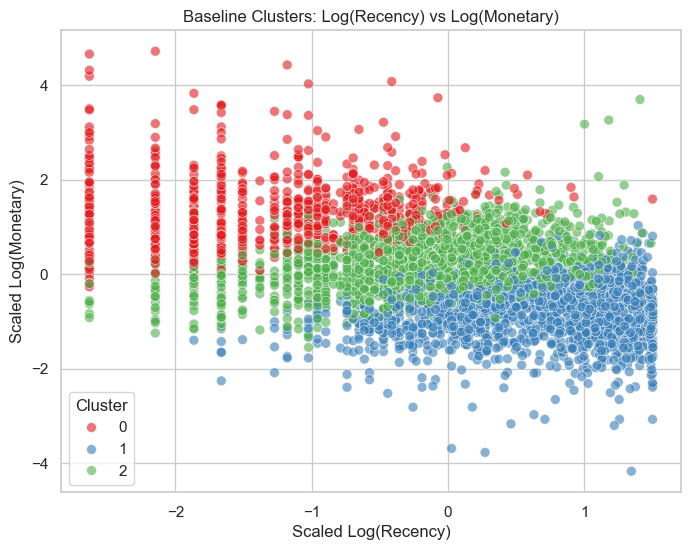

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=rfm_scaled_df['Recency'], y=rfm_scaled_df['Monetary'], 
                hue=rfm_scaled_df['Baseline_Cluster'], palette='Set1', s=50, alpha=0.6)
plt.title('Baseline Clusters: Log(Recency) vs Log(Monetary)')
plt.xlabel('Scaled Log(Recency)')
plt.ylabel('Scaled Log(Monetary)')
plt.legend(title='Cluster')
plt.savefig('../reports/figures/baseline_clusters.png', dpi=300)
plt.show()

## 5. Baseline Evaluation Summary

### Why this is the baseline
K-Means with K=3 provides a universally understood, fast, and highly interpretable "High / Medium / Low" grouping. 

### Assumptions
* Assumes spherical clusters with similar variance.
* Assumes every data point belongs strictly to one cluster.

### Strengths
* Simple to understand and explain to business stakeholders.
* Computationally very fast.

### Weaknesses
* Arbitrarily choosing K=3 might force unnatural groupings.
* Highly sensitive to the shape of the data (struggles with non-spherical clusters).

### Next Steps
In Phase 7, we will explore optimal K-selection methods and alternative clustering algorithms like Agglomerative Clustering and DBSCAN to see if they can achieve better separation or more meaningful business segments.